In [2]:
import re
import glob
import json
import matplotlib.pyplot as plt

def parse_perf_file(filepath):
    with open(filepath, 'r') as f:
        text = f.read()
    
    # split into blocks, each starting with "Request Rate:"
    blocks = re.split(r'(?=Request Rate: \d)', text)
    
    results = []
    for block in blocks:
        if 'Request Rate:' not in block:
            continue
        
        m = re.search(r'Request Rate: ([\d.]+) inference', block)
        request_rate = float(m.group(1)) if m else None

        m = re.search(r'Throughput: ([\d.]+) infer/sec', block)
        throughput = float(m.group(1)) if m else None

        m = re.search(r'queue (\d+) usec', block)
        queue_time_ms = int(m.group(1)) / 1000 if m else None

        m = re.search(r'compute infer (\d+) usec', block)
        compute_infer_ms = int(m.group(1)) / 1000 if m else None

        m_infer = re.search(r'Inference count: (\d+)', block)
        m_exec  = re.search(r'Execution count: (\d+)', block)
        avg_batch_size = None
        if m_infer and m_exec:
            infer = int(m_infer.group(1))
            execc = int(m_exec.group(1))
            avg_batch_size = round(infer / execc, 3) if execc > 0 else None

        unstable = 'not stabilizing' in block.lower() or 'were delayed' in block

        if request_rate:
            results.append({
                'request_rate': request_rate,
                'throughput': throughput,
                'queue_time_ms': queue_time_ms,
                'compute_infer_ms': compute_infer_ms,
                'avg_batch_size': avg_batch_size,
                'unstable': unstable
            })
    
    return results



# --- Load perf files ---
all_results = []
for f in glob.glob('/home/jovyan/work/batch_8_results/batch_8_*.txt'):
    all_results.extend(parse_perf_file(f))

results = sorted(all_results, key=lambda r: r['request_rate'])
# --- Print table ---
print(f"{'Request Rate':>14} {'Queue Time (ms)':>16} {'Compute Infer (ms)':>20} {'Avg Batch Size':>16} {'Stable':>8}")
print("-" * 78)
for r in results:
    qt  = f"{r['queue_time_ms']:>16.3f}"  if r['queue_time_ms']  is not None else f"{'N/A':>16}"
    ci  = f"{r['compute_infer_ms']:>20.3f}" if r['compute_infer_ms'] is not None else f"{'N/A':>20}"
    bs  = f"{r['avg_batch_size']:>16.3f}"  if r['avg_batch_size']  is not None else f"{'N/A':>16}"
    print(f"{r['request_rate']:>14.1f} {qt} {ci} {bs} {'No' if r['unstable'] else 'Yes':>8}")

  Request Rate  Queue Time (ms)   Compute Infer (ms)   Avg Batch Size   Stable
------------------------------------------------------------------------------
          20.0              N/A                  N/A              N/A      Yes
         120.0            2.058                4.744            1.103      Yes
         140.0            2.083                4.465            1.124      Yes
         160.0            2.103                4.115            1.140      Yes
         180.0            2.026                3.804            1.147      Yes
         200.0            1.926                3.484            1.157      Yes
         220.0            1.921                3.402            1.191       No
         240.0            1.924                3.207            1.207       No
         260.0            1.875                3.025            1.217       No
         280.0            2.002                3.084            1.248       No
         300.0            2.102                3.074

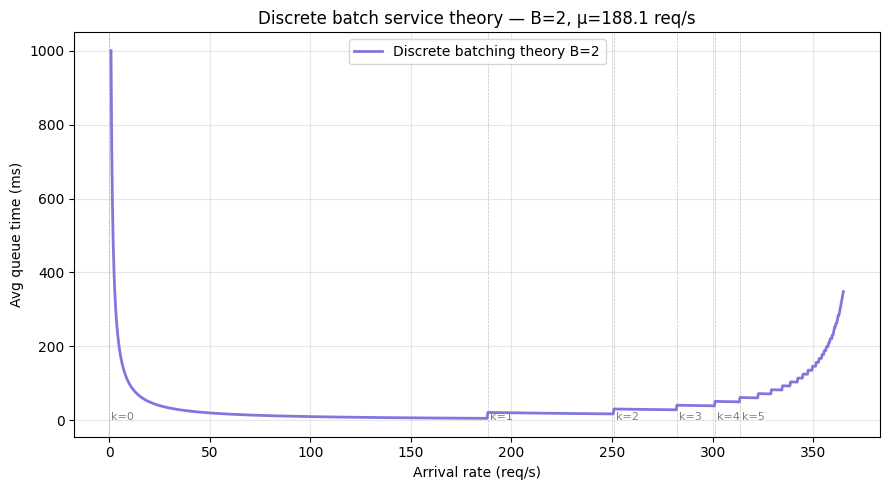

In [16]:
import numpy as np
import matplotlib.pyplot as plt

B = 2
mu = 1000 / np.mean([r['compute_infer_ms'] for r in stable[:5]])
E_S = 1 / mu  # service time per batch execution

# inter-arrival time at each lambda
lam_range = np.linspace(1, mu * B * 0.97, 1000)

theory_wq = []
for lam in lam_range:
    rho = lam / (mu * B)
    if rho >= 1:
        theory_wq.append(None)
        continue
    
    # time to fill one batch = B / lam (deterministic arrivals would be exact)
    T_fill = B / lam
    
    # a request waits on average T_fill/2 to fill current batch
    # plus k full service cycles based on utilization
    # k = floor of how many batch cycles are backlogged
    E_batches_backlog = rho / (1 - rho)
    k = int(E_batches_backlog)  # discrete floor — this creates the steps
    
    wq = (T_fill / 2) + k * (E_S + T_fill)
    theory_wq.append(wq * 1000)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lam_range, theory_wq, '-', color='#7F77DD', linewidth=2, label=f'Discrete batching theory B={B}')

# mark step boundaries
for k in range(6):
    # rho at which k-th step occurs: k = floor(rho/(1-rho)) -> rho = k/(k+1)
    rho_k = k / (k + 1)
    lam_k = rho_k * mu * B
    if lam_k < mu * B * 0.97:
        ax.axvline(x=lam_k, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
        ax.text(lam_k + 1, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0.1,
                f'k={k}', fontsize=8, color='gray')

ax.set_xlabel('Arrival rate (req/s)')
ax.set_ylabel('Avg queue time (ms)')
ax.set_title(f'Discrete batch service theory — B={B}, μ={mu:.1f} req/s')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/jovyan/work/batch_2_results/theory_discrete_batch2.png', dpi=150)
plt.show()

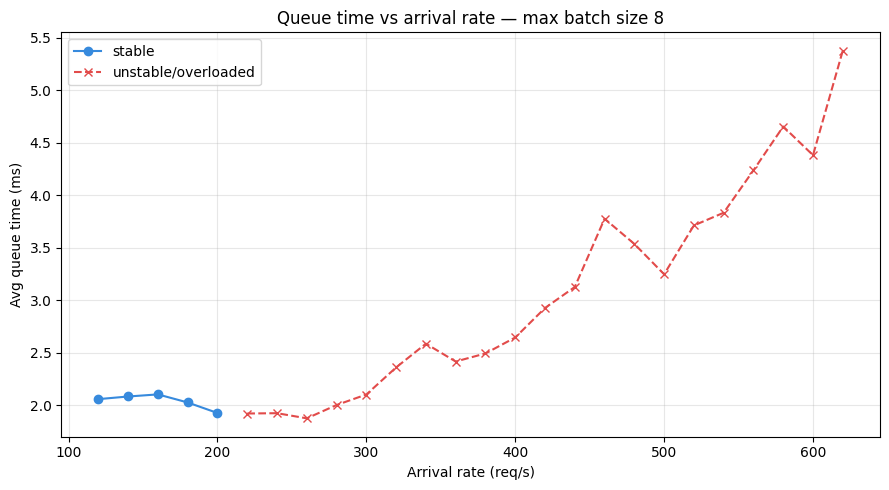

In [6]:

# --- Plot ---
stable   = [r for r in results if not r['unstable']]
unstable = [r for r in results[:-18] if r['unstable']]

fig, ax = plt.subplots(figsize=(9, 5))

if stable:
    ax.plot([r['request_rate'] for r in stable],
            [r['queue_time_ms'] for r in stable],
            'o-', color='#378ADD', label='stable')
if unstable[:-1]:
    ax.plot([r['request_rate'] for r in unstable[:-1]],
            [r['queue_time_ms'] for r in unstable[:-1]],
            'x--', color='#E24B4A', label='unstable/overloaded')
#ax.plot(lam_range, theory_wq, '-', color='#1D9E75', linewidth=1.5, label='M/D/1 batch theory')
ax.set_xlabel('Arrival rate (req/s)')
ax.set_ylabel('Avg queue time (ms)')
ax.set_title('Queue time vs arrival rate — max batch size 8')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/jovyan/work/batch_8_results/queue_vs_rate_batch8.png', dpi=150)
plt.show()
